# Getting Data from Drive

In [1]:
!pip install gdown

In [2]:
file_id = '1zoxILwlO47YV1rWCzAAVu7AE2JItUTDY' 
!gdown --id $file_id

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1zoxILwlO47YV1rWCzAAVu7AE2JItUTDY
From (redirected): https://drive.google.com/uc?id=1zoxILwlO47YV1rWCzAAVu7AE2JItUTDY&confirm=t&uuid=da5eb179-b07f-426b-81d6-c63c8620e3ce
To: /kaggle/working/data-20260220T142928Z-1-001.zip
100%|██████████████████████████████████████| 68.7M/68.7M [00:01<00:00, 39.8MB/s]


In [3]:
!unzip data-20260220T142928Z-1-001.zip

Archive:  data-20260220T142928Z-1-001.zip
  inflating: data/labels/138_39.png  
  inflating: data/labels/141_237.png  
  inflating: data/labels/144_235.png  
  inflating: data/labels/123_145.png  
  inflating: data/labels/143_183.png  
  inflating: data/labels/140_34.png  
  inflating: data/labels/134_153.png  
  inflating: data/labels/145_164.png  
  inflating: data/labels/147_213.png  
  inflating: data/labels/129_177.png  
  inflating: data/labels/124_95.png  
  inflating: data/labels/119_222.png  
  inflating: data/labels/132_126.png  
  inflating: data/labels/146_84.png  
  inflating: data/labels/137_140.png  
  inflating: data/labels/133_224.png  
  inflating: data/labels/149_166.png  
  inflating: data/labels/135_56.png  
  inflating: data/labels/125_201.png  
  inflating: data/labels/126_110.png  
  inflating: data/labels/142_238.png  
  inflating: data/labels/139_108.png  
  inflating: data/labels/121_142.png  
  inflating: data/labels/128_294.png  
  inflating: data/labels/13

# Data Discovery

In [4]:
import os
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [5]:
class WaterDataset(Dataset):
    def __init__(self, images_dir, labels_dir, normalize=True):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        
        self.image_files = sorted(os.listdir(images_dir))
        self.label_files = sorted(os.listdir(labels_dir))
        
        self.normalize = normalize

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        
        # ----- Load Multispectral Image -----
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        
        with rasterio.open(image_path) as src:
            image = src.read()  # shape: (12, 128, 128)
        
        image = image.astype(np.float32)
        
        # ----- Normalize per band -----
        if self.normalize:
            for c in range(image.shape[0]):
                band = image[c]
                min_val = band.min()
                max_val = band.max()
                if max_val - min_val > 0:
                    image[c] = (band - min_val) / (max_val - min_val)

        # ----- Load Mask -----
        label_path = os.path.join(self.labels_dir, self.label_files[idx])
        label = np.array(Image.open(label_path))
        
        # Ensure binary
        label = (label > 0).astype(np.float32)

        return torch.tensor(image), torch.tensor(label).unsqueeze(0)

In [6]:
data_path = "/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data"

images_dir = os.path.join(data_path, "images")
labels_dir = os.path.join(data_path, "labels")

dataset = WaterDataset(images_dir, labels_dir, normalize=True)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


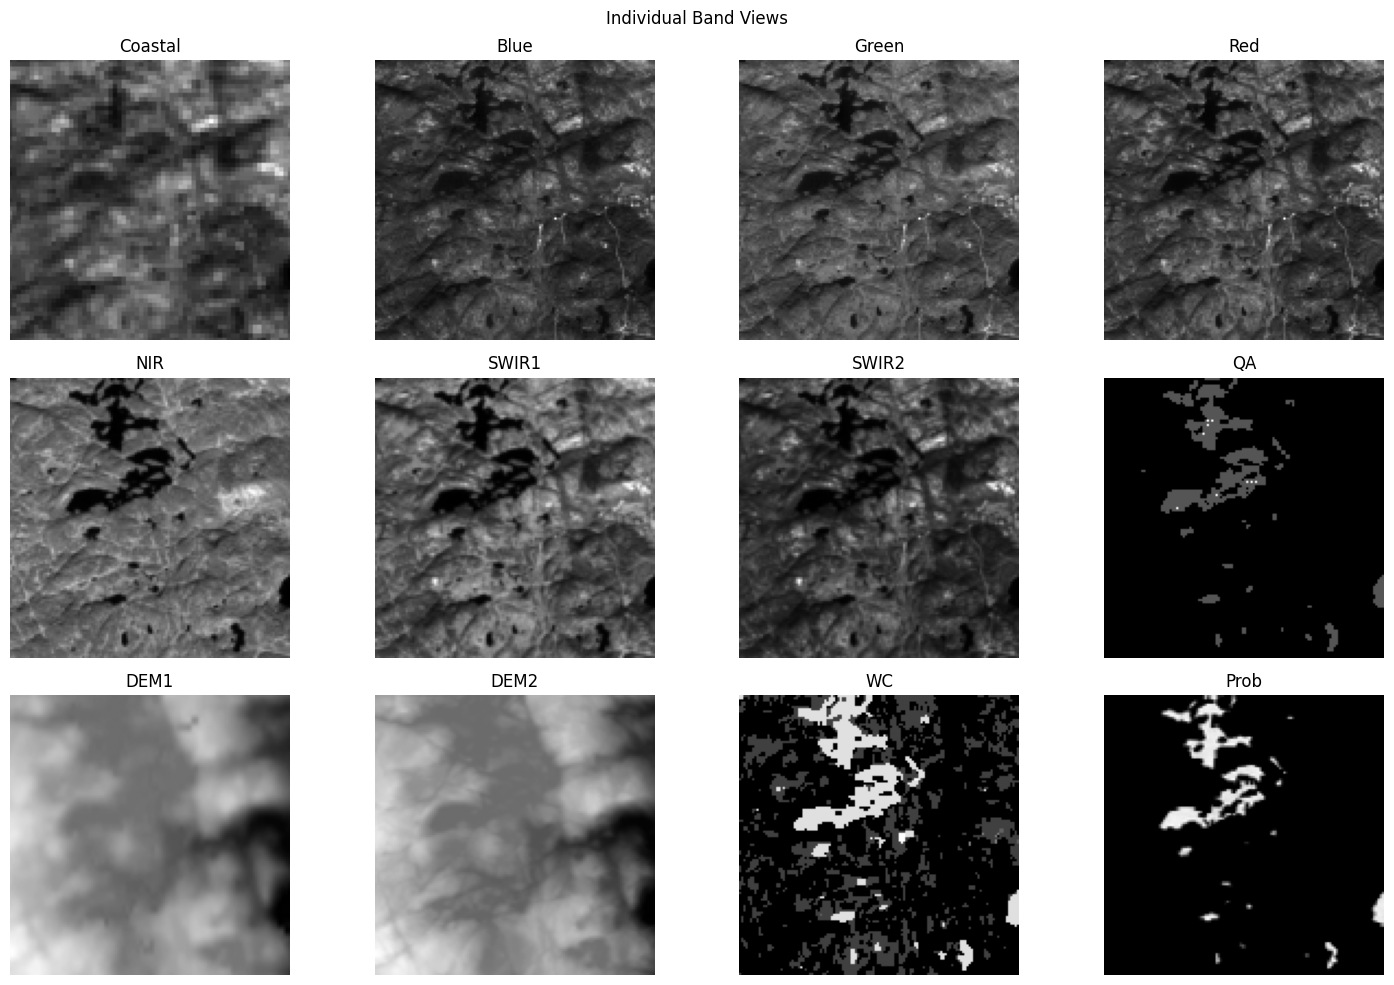

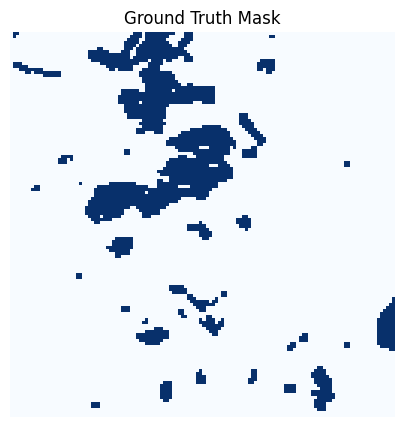

In [7]:
def vis_sample(dataset, idx=0):
    img, mask = dataset[idx]
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    band_names = ['Coastal', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA', 'DEM1', 'DEM2', 'WC', 'Prob']
    
    for i in range(12):
        ax = axes[i // 4, i % 4]
        ax.imshow(img[i], cmap='gray')
        ax.set_title(band_names[i])
        ax.axis('off')
    
    plt.suptitle('Individual Band Views')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(5,5))
    plt.imshow(mask[0], cmap='Blues')
    plt.title('Ground Truth Mask')
    plt.axis('off')
    plt.show()

vis_sample(dataset, idx=0)

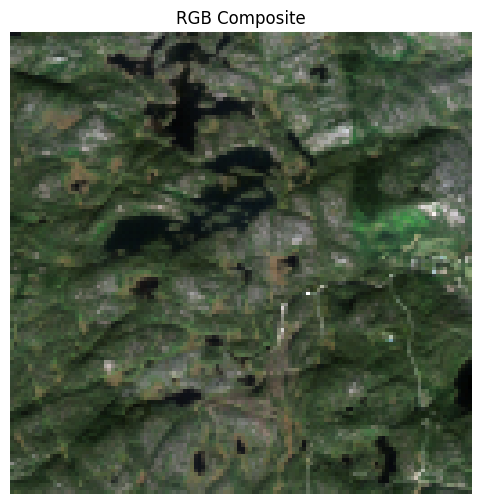

In [8]:
def visualize_rgb(dataset, index=0, r=3, g=2, b=1):
    image, label = dataset[index]
    image = image.numpy()
    label = label.squeeze().numpy()

    rgb = np.stack([image[r], image[g], image[b]], axis=-1)

    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title("RGB Composite")
    plt.axis("off")
    plt.show()

visualize_rgb(dataset)

# Another Data Discovery Approach

In [9]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
import torch.nn.functional as F

In [10]:
KAGGLE_ROOT = '/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data'
LOCAL_ROOT = 'data/'

DATA_ROOT = KAGGLE_ROOT if os.path.exists(KAGGLE_ROOT) else LOCAL_ROOT
IMAGE_DIR = os.path.join(DATA_ROOT, 'images')
LABEL_DIR = os.path.join(DATA_ROOT, 'labels')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device}. Data root: {DATA_ROOT}')

Using cuda. Data root: /kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data


In [11]:
all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.tif')))
all_labels = [os.path.join(LABEL_DIR, os.path.basename(f).replace('.tif', '.png')) for f in all_images]

indices = np.arange(len(all_images))
np.random.seed(42)
np.random.shuffle(indices)

split_1 = int(0.7 * len(indices))
split_2 = int(0.85 * len(indices))

train_idx = indices[:split_1]
val_idx = indices[split_1:split_2]
test_idx = indices[split_2:]

train_images = [all_images[i] for i in train_idx]
train_labels = [all_labels[i] for i in train_idx]
val_images = [all_images[i] for i in val_idx]
val_labels = [all_labels[i] for i in val_idx]
test_images = [all_images[i] for i in test_idx]
test_labels = [all_labels[i] for i in test_idx]

print(f'Training Samples: {len(train_images)}')
print(f'Validation Samples: {len(val_images)}')
print(f'Testing Samples: {len(test_images)}')

Training Samples: 214
Validation Samples: 46
Testing Samples: 46


In [12]:
def get_train_stats(image_paths):
    print('Scanning training set for statistics...')
    sums = np.zeros(12)
    sq_sums = np.zeros(12)
    total_px = len(image_paths) * 128 * 128
    
    for p in image_paths:
        with rasterio.open(p) as src:
            img = src.read().astype(np.float32)
            for c in range(12):
                sums[c] += img[c].sum()
                sq_sums[c] += (img[c]**2).sum()
    
    means = sums / total_px
    stds = np.sqrt((sq_sums / total_px) - (means**2))
    return means, stds

TRAIN_MEAN, TRAIN_STD = get_train_stats(train_images)
print(f'Global Means: {TRAIN_MEAN}')
print(f'Global Stds: {TRAIN_STD}')

Scanning training set for statistics...
Global Means: [ 403.15005065  503.16623666  834.16918974  999.31952332 2100.34661865
 2034.36808877 1415.9676026   102.23663786  128.47990803  307.73551927
   34.99336314    9.61554098]
Global Stds: [ 262.85113647  321.53453456  417.70256791  595.66919345 1043.92750111
 1219.19713944  994.86205654   48.49544132 1442.54030462  507.31194915
   19.91716032   27.61763356]


In [13]:
class WaterDataset(Dataset):
    def __init__(self, image_paths, label_paths, means, stds):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.means = torch.tensor(means).float().view(12, 1, 1)
        self.stds = torch.tensor(stds).float().view(12, 1, 1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.image_paths[idx]) as src:
            image = torch.from_numpy(src.read().astype(np.float32))
        
        label = np.array(Image.open(self.label_paths[idx]))
        label = torch.from_numpy((label > 0).astype(np.float32)).unsqueeze(0)
        
        # Apply Global Normalization
        image = (image - self.means) / (self.stds + 1e-6)
        return image, label

train_loader = DataLoader(WaterDataset(train_images, train_labels, TRAIN_MEAN, TRAIN_STD), batch_size=8, shuffle=True)
val_loader = DataLoader(WaterDataset(val_images, val_labels, TRAIN_MEAN, TRAIN_STD), batch_size=8, shuffle=False)
test_loader = DataLoader(WaterDataset(test_images, test_labels, TRAIN_MEAN, TRAIN_STD), batch_size=8, shuffle=False)

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=12):
        super().__init__()
        self.e1 = ConvBlock(in_channels, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.u1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d1 = ConvBlock(256 * 1, 128) # Cat logic fixed below
        self.u2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d2 = ConvBlock(128, 64)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        c1 = self.e1(x)
        p1 = self.pool(c1)
        c2 = self.e2(p1)
        p2 = self.pool(c2)
        c3 = self.e3(p2)
        
        u1 = self.u1(c3)
        d1 = self.d1(torch.cat([u1, c2], dim=1))
        u2 = self.u2(d1)
        d2 = self.d2(torch.cat([u2, c1], dim=1))
        return torch.sigmoid(self.out(d2))

model = UNet(in_channels=12).to(device)

In [15]:
def dice_loss(pred, target):
    pred, target = pred.view(-1), target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

def evaluate_metrics(loader, model):
    model.eval()
    ious, precs, recs = [], [], []
    with torch.no_grad():
        for img, mask in loader:
            img, mask = img.to(device), mask.to(device)
            pred = (model(img) > 0.5).float()
            tp = (pred * mask).sum().item()
            fp = (pred * (1-mask)).sum().item()
            fn = ((1-pred) * mask).sum().item()
            union = (pred + mask).clamp(0, 1).sum().item()
            
            ious.append((tp + 1e-6) / (union + 1e-6))
            precs.append((tp + 1e-6) / (tp + fp + 1e-6))
            recs.append((tp + 1e-6) / (tp + fn + 1e-6))
            
    return np.mean(ious), np.mean(precs), np.mean(recs)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.BCELoss()

print('Starting Training...')
for epoch in range(5):
    model.train()
    train_loss = 0
    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)
        optimizer.zero_grad()
        out = model(img)
        loss = loss_fn(out, mask) + dice_loss(out, mask)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    iou, prec, rec = evaluate_metrics(val_loader, model)
    print(f'Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val IoU: {iou:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}')
    

Starting Training...


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch 1 | Loss: 1.2796 | Val IoU: 0.4628 | Prec: 0.9679 | Rec: 0.4732
Epoch 2 | Loss: 0.7157 | Val IoU: 0.5921 | Prec: 0.8027 | Rec: 0.6908
Epoch 3 | Loss: 0.5952 | Val IoU: 0.6150 | Prec: 0.8930 | Rec: 0.6649
Epoch 4 | Loss: 0.5564 | Val IoU: 0.6189 | Prec: 0.8923 | Rec: 0.6698
Epoch 5 | Loss: 0.5488 | Val IoU: 0.6167 | Prec: 0.9062 | Rec: 0.6614


# Preprocessing

In [16]:
import rasterio
import numpy as np
from PIL import Image

def load_patch(image_path, mask_path):
    # Load TIFF
    with rasterio.open(image_path) as src:
        image = src.read()                 # shape = (channels, height, width)
        image = np.transpose(image, (1, 2, 0))  # convert to (height, width, channels)
    
    # Load mask
    mask = np.array(Image.open(mask_path))     # shape = (height, width)
    
    return image, mask

# Example usage
image, mask = load_patch('/kaggle/working/data/images/0.tif',
                         '/kaggle/working/data/labels/0.png')
print(image.shape, mask.shape)  # (128,128,12), (128,128)

(128, 128, 12) (128, 128)


In [17]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from torchvision import transforms
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [18]:
IMAGE_DIR = '/kaggle/working/data/images'
LABEL_DIR = '/kaggle/working/data/labels'

# Map images to labels by filename base (e.g., 0.tif -> 0.png)
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.tif')))
valid_images = []
valid_labels = []

for img_path in image_paths:
    basename = os.path.basename(img_path).replace('.tif', '')
    label_path = os.path.join(LABEL_DIR, f'{basename}.png')
    if os.path.exists(label_path):
        valid_images.append(img_path)
        valid_labels.append(label_path)

print(f'Found {len(valid_images)} matching pairs.')

Found 306 matching pairs.


In [19]:
class WaterDataset(Dataset):
    def __init__(self, image_paths, label_paths):
        self.image_paths = image_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load 12-band image using rasterio
        with rasterio.open(self.image_paths[idx]) as src:
            image = src.read() # (12, 128, 128)
            
        # Load label mask
        label = np.array(Image.open(self.label_paths[idx])) # (128, 128)
        label = (label > 0).astype(np.float32) # Ensure binary
        
        # Normalization per channel to [0, 1]
        image = image.astype(np.float32)
        for c in range(image.shape[0]):
            c_min = image[c].min()
            c_max = image[c].max()
            if c_max > c_min:
                image[c] = (image[c] - c_min) / (c_max - c_min)
            else:
                image[c] = 0.0
                
        return torch.from_numpy(image), torch.from_numpy(label).unsqueeze(0)

dataset = WaterDataset(valid_images, valid_labels)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader = DataLoader(val_data, batch_size=8, shuffle=False)

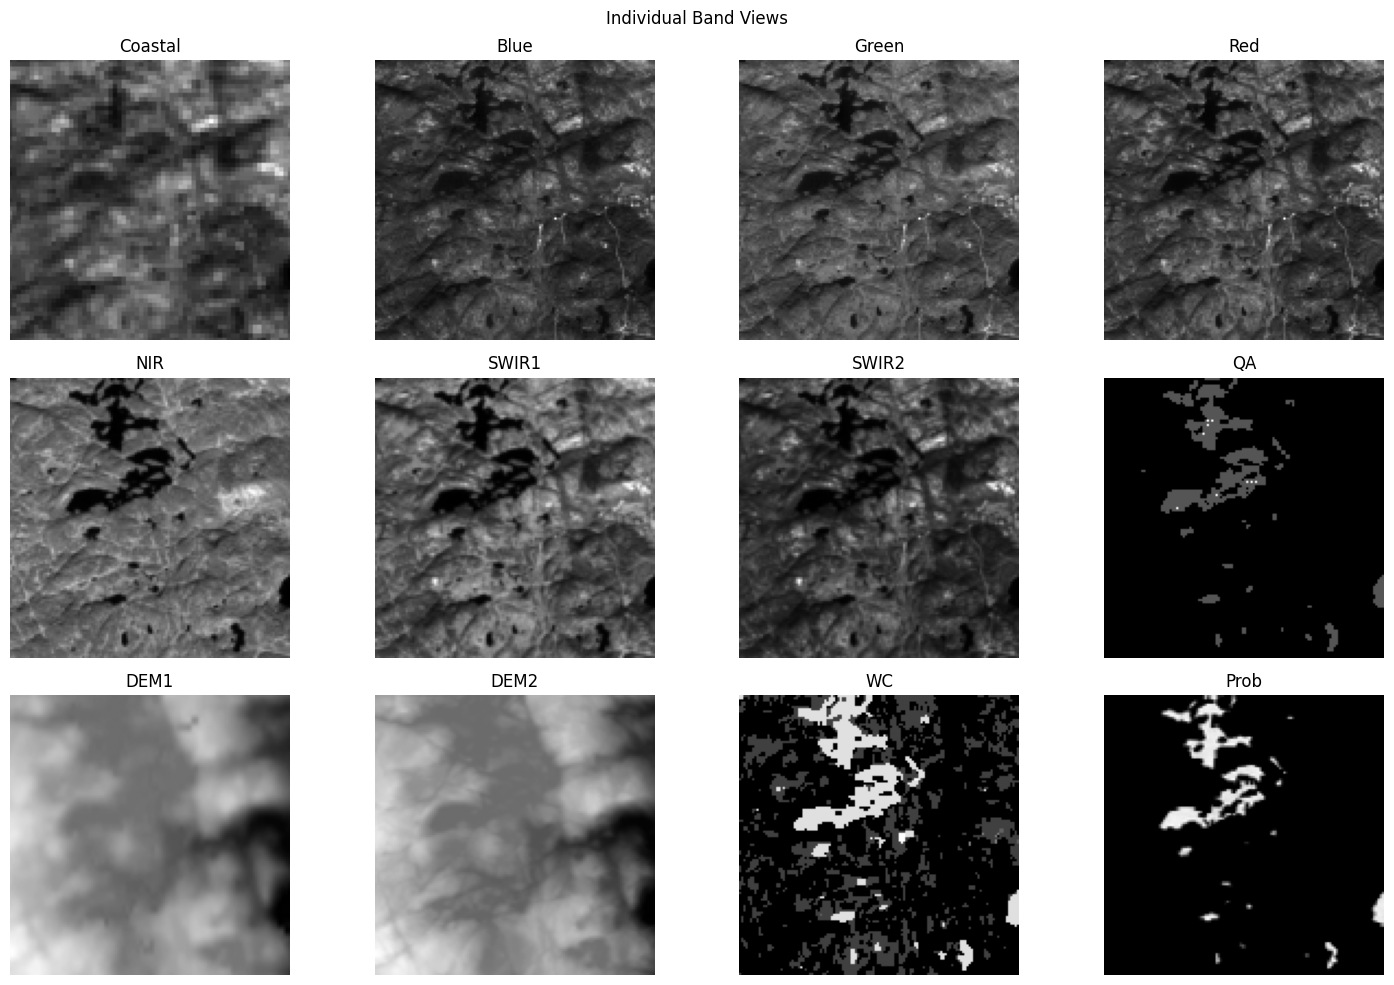

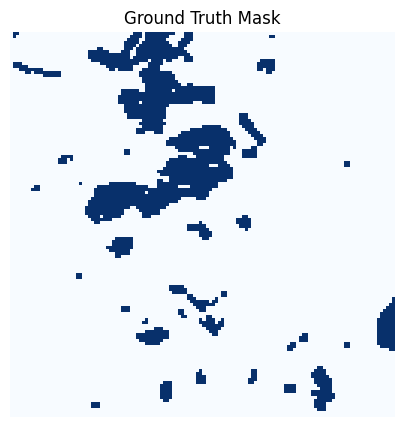

In [20]:
def visualize_sample(dataset, idx=0):
    img, mask = dataset[idx]
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    band_names = ['Coastal', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA', 'DEM1', 'DEM2', 'WC', 'Prob']
    
    for i in range(12):
        ax = axes[i // 4, i % 4]
        ax.imshow(img[i], cmap='gray')
        ax.set_title(band_names[i])
        ax.axis('off')
    
    plt.suptitle('Individual Band Views')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(5,5))
    plt.imshow(mask[0], cmap='Blues')
    plt.title('Ground Truth Mask')
    plt.axis('off')
    plt.show()

visualize_sample(dataset, idx=0)